In [1]:
#main.ipynb
#AAI-551 Final Project

"""
Team Members
-Pranav Itikarlapalli
-Ishaan Bhalodia
"""

'\nTeam Members\n-Pranav Itikarlapalli\n-Ishaan Bhalodia\n'

In [2]:
from account import Account
from fraud_detector import FraudDetector, InsufficientDataError, InvalidTransactionError
from data_io import (
    save_transactions_to_csv,
    load_transactions_from_csv,
    save_accounts_to_csv,
    load_accounts_from_csv,
    EmptyDataError,
    CSVReadError,
)
from transaction_simulator import simulate_transaction_stream, generate_sample_transactions
from visualizer import plot_transaction_amounts, plot_balance_comparison
import pandas as pd

In [3]:
# Creating Accounts

alice  = Account("A001", "Alice Smith",   1000.0)
bob    = Account("A002", "Bob Johnson",    500.0)
carol  = Account("A003", "Carol White",    750.0)
david  = Account("A004", "David Lee",      300.0)
eve    = Account("A005", "Eve Martinez",   600.0)
frank  = Account("A006", "Frank Turner",   450.0)

print("Accounts:")
print(alice)
print(bob)
print(carol)
print(david)
print(eve)
print(frank)

# Edge case — negative initial balance
print()
try:
    Account("A000", "Bad User", -500.0)
except ValueError as e:
    print(f"Negative initial balance -> ValueError: {e}")

Accounts:
Account(A001): Alice Smith | Balance: $1000.00 | Transactions: 1
Account(A002): Bob Johnson | Balance: $500.00 | Transactions: 1
Account(A003): Carol White | Balance: $750.00 | Transactions: 1
Account(A004): David Lee | Balance: $300.00 | Transactions: 1
Account(A005): Eve Martinez | Balance: $600.00 | Transactions: 1
Account(A006): Frank Turner | Balance: $450.00 | Transactions: 1

Negative initial balance -> ValueError: Initial balance cannot be negative


In [4]:
# Recording Normal Transactions

#Alice - typical deposits around 100
for amount in [95.0, 110.0, 105.0, 98.0, 102.0]:
    alice.deposit(amount)

#Bob - typical deposits around 200
for amount in [190.0, 210.0, 195.0, 205.0, 200.0]:
    bob.deposit(amount)

#Carol - typical deposits around 150
for amount in [145.0, 155.0, 150.0, 148.0, 152.0]:
    carol.deposit(amount)

#David — typical deposits around $50
for amount in [45.0, 55.0, 50.0, 48.0, 52.0]:
    david.deposit(amount)

#Eve — typical deposits around $300
for amount in [290.0, 310.0, 295.0, 305.0, 300.0]:
    eve.deposit(amount)

#Frank — typical deposits around $80
for amount in [75.0, 85.0, 80.0, 78.0, 82.0]:
    frank.deposit(amount)

for acc in [alice, bob, carol, david, eve, frank]:
    print(f"{acc.owner_name:<15} : {len(acc.transaction_history)} transactions : Balance: ${acc.balance:.2f}")

# Edge cases — deposit exceptions
print()
try:
    alice.deposit(-50.0)
except ValueError as e:
    print(f"Negative deposit -> ValueError: {e}")

try:
    alice.deposit(0)
except ValueError as e:
    print(f"Zero deposit -> ValueError: {e}")

Alice Smith     : 6 transactions : Balance: $1510.00
Bob Johnson     : 6 transactions : Balance: $1500.00
Carol White     : 6 transactions : Balance: $1500.00
David Lee       : 6 transactions : Balance: $550.00
Eve Martinez    : 6 transactions : Balance: $2100.00
Frank Turner    : 6 transactions : Balance: $850.00

Negative deposit -> ValueError: Deposit amount must be positive, got -50.0
Zero deposit -> ValueError: Deposit amount must be positive, got 0


In [5]:
bob.withdraw(100.0)
print(f"Bob withdrew $100.00   | New balance: ${bob.balance:.2f}")

carol.withdraw(200.0)
print(f"Carol withdrew $200.00 | New balance: ${carol.balance:.2f}")

david.withdraw(50.0)
print(f"David withdrew $50.00  | New balance: ${david.balance:.2f}")

# Edge cases — withdrawal exceptions

try:
    frank.withdraw(-50.0)
except ValueError as e:
    print(f"Negative withdrawal -> ValueError: {e}")

print()
#Edge cases - withdrawal exceptions
try:
    frank.withdraw(0)
except ValueError as e:
    print(f"Zero withdrawal -> ValueError: {e}")

try:
    david.withdraw(99999.0)
except ValueError as e:
    print(f"Exceeds balance -> ValueError: {e}")

Bob withdrew $100.00   | New balance: $1400.00
Carol withdrew $200.00 | New balance: $1300.00
David withdrew $50.00  | New balance: $500.00
Negative withdrawal -> ValueError: Withdrawal amount must be positive, got -50.0

Zero withdrawal -> ValueError: Withdrawal amount must be positive, got 0
Exceeds balance -> ValueError: Insufficient funds. Balance: 500.0, Withdrawal: 99999.0


In [6]:
# Transferring Between Accounts

print(f"Before — Alice: ${alice.balance:.2f} | Bob: ${bob.balance:.2f}")
alice.transfer(50.0, bob)
print(f"Alice -> Bob $50.00 | Alice: ${alice.balance:.2f} | Bob: ${bob.balance:.2f}")

print(f"Before — Eve: ${eve.balance:.2f} | Carol: ${carol.balance:.2f}")
eve.transfer(150.0, carol)
print(f"Eve -> Carol $150.00 | Eve: ${eve.balance:.2f} | Carol: ${carol.balance:.2f}")

print(f"Before — Frank: ${frank.balance:.2f} | David: ${david.balance:.2f}")
frank.transfer(100.0, david)
print(f"Frank -> David $100.00 | Frank: ${frank.balance:.2f} | David: ${david.balance:.2f}")

# Edge cases — transfer exceptions
print()
try:
    frank.transfer(-100.0, alice)
except ValueError as e:
    print(f"Negative transfer -> ValueError: {e}")

try:
    frank.transfer(0, alice)
except ValueError as e:
    print(f"Zero transfer -> ValueError: {e}")

try:
    david.transfer(99999.0, alice)
except ValueError as e:
    print(f"Exceeds balance -> ValueError: {e}")





Before — Alice: $1510.00 | Bob: $1400.00
Alice -> Bob $50.00 | Alice: $1460.00 | Bob: $1450.00
Before — Eve: $2100.00 | Carol: $1300.00
Eve -> Carol $150.00 | Eve: $1950.00 | Carol: $1450.00
Before — Frank: $850.00 | David: $500.00
Frank -> David $100.00 | Frank: $750.00 | David: $600.00

Negative transfer -> ValueError: Transfer amount must be positive, got -100.0
Zero transfer -> ValueError: Transfer amount must be positive, got 0
Exceeds balance -> ValueError: Insufficient funds for transfer. Balance: 600.0


In [7]:
# Transaction History

amounts = alice.get_transaction_amounts()
print(f"Alice's transaction amounts : {amounts}")
print(f"Total transactions recorded : {len(alice.transaction_history)}")

print()
print("Last 3 transactions:")
for txn in alice.transaction_history[-3:]:
    print(f"{txn['type']:<15} | ${txn['amount']:.2f} | balance after: ${txn['balance_after']:.2f}")

Alice's transaction amounts : [1000.0, 95.0, 110.0, 105.0, 98.0, 102.0, -50.0]
Total transactions recorded : 7

Last 3 transactions:
deposit         | $98.00 | balance after: $1408.00
deposit         | $102.00 | balance after: $1510.00
transfer_out    | $50.00 | balance after: $1460.00


In [8]:
# Operator Overloading

# __add__ — combined balance of two accounts
combined = alice + bob
print(f"Alice + Bob combined balance: ${combined:.2f}")

combined2 = eve + carol
print(f"Eve + Carol combined balance: ${combined2:.2f}")

# __str__ — readable string, called implicitly in f-strings
print(f"str(alice) -> {alice}")
print(f"str(frank) -> {frank}")

# __repr__ — developer representation
print(f"repr(bob) -> {repr(bob)}")
print(f"repr(david) -> {repr(david)}")

# Edge case — adding a non-Account returns NotImplemented
print()
result = alice.__add__("not_an_account")
print(f"alice + string -> {result}")

Alice + Bob combined balance: $2910.00
Eve + Carol combined balance: $3400.00
str(alice) -> Account(A001): Alice Smith | Balance: $1460.00 | Transactions: 7
str(frank) -> Account(A006): Frank Turner | Balance: $750.00 | Transactions: 7
repr(bob) -> Account('A002', 'Bob Johnson', 1450.0)
repr(david) -> Account('A004', 'David Lee', 600.0)

alice + string -> NotImplemented


In [9]:
# Fraud Detection Single Transaction

detector = FraudDetector(threshold=2.0, min_history=3)
print(detector)

for amount in [103.0, 9999.0, 97.0, 5000.0]:
    is_fraud = detector.analyze_transaction(alice, amount)
    status = "FLAGGED" if is_fraud else "OK"
    print(f"  ${amount:>8.2f}  ->  {status}")

FraudDetector(threshold=2.0, min_history=3, flags_this_session=0)
  $  103.00  ->  OK
  $ 9999.00  ->  FLAGGED
  $   97.00  ->  OK
  $ 5000.00  ->  FLAGGED


In [10]:
for acc in [bob, david]:
    history = [
        t["amount"] for t in acc.transaction_history
        if t["type"] not in ("initial_deposit", "withdrawal", "transfer_out")
    ]
    print(f"{acc.owner_name}: {history}")

Bob Johnson: [190.0, 210.0, 195.0, 205.0, 200.0, 50.0]
David Lee: [45.0, 55.0, 50.0, 48.0, 52.0, 100.0]


In [11]:
# Full Account Analysis
for account in [alice, bob, carol, david, eve, frank]:
    summary = detector.analyze_account(account)
    print(f"\n {summary['owner']} ({summary['account_id']})")
    print(f" Transactions : {summary['transaction_count']}")
    print(f" Mean : ${summary['mean']:.2f}")
    print(f" Std Dev : ${summary['std']:.2f}")
    print(f" Min / Max : ${summary['min']:.2f} / ${summary['max']:.2f}")
    print(f" Flagged : {summary['flagged_count']}")

# Flagged Transactions




 Alice Smith (A001)
 Transactions : 5
 Mean : $102.00
 Std Dev : $5.25
 Min / Max : $95.00 / $110.00
 Flagged : 0

 Bob Johnson (A002)
 Transactions : 5
 Mean : $200.00
 Std Dev : $7.07
 Min / Max : $190.00 / $210.00
 Flagged : 0

 Carol White (A003)
 Transactions : 5
 Mean : $150.00
 Std Dev : $3.41
 Min / Max : $145.00 / $155.00
 Flagged : 0

 David Lee (A004)
 Transactions : 5
 Mean : $50.00
 Std Dev : $3.41
 Min / Max : $45.00 / $55.00
 Flagged : 0

 Eve Martinez (A005)
 Transactions : 5
 Mean : $300.00
 Std Dev : $7.07
 Min / Max : $290.00 / $310.00
 Flagged : 0

 Frank Turner (A006)
 Transactions : 5
 Mean : $80.00
 Std Dev : $3.41
 Min / Max : $75.00 / $85.00
 Flagged : 0


In [12]:
flags = detector.get_flagged_transactions()

print(f"Total flagged: {len(flags)}")
for flag in flags:
    print(f"{flag['account_id']} | ${flag['flagged_amount']:.2f} | z={flag['z_score']:.4f}")

Total flagged: 2
A001 | $9999.00 | z=1883.8618
A001 | $5000.00 | z=932.3184


In [14]:
# Fraud Detector Exception Handling

# InsufficientDataError — account with no history
new_acc = Account("A999", "New User", 100.0)
try:
    detector.analyze_transaction(new_acc, 50.0)
except InsufficientDataError as e:
    print(f"InsufficientDataError  : {e}")

# InvalidTransactionError — negative amount
try:
    detector.analyze_transaction(alice, -100.0)
except InvalidTransactionError as e:
    print(f"InvalidTransactionError: {e}")

# TypeError — non-Account passed in
try:
    detector.analyze_transaction("not_an_account", 100.0)
except TypeError as e:
    print(f"TypeError : {e}")

# ValueError — bad threshold
try:
    FraudDetector(threshold=0)
except ValueError as e:
    print(f"ValueError : {e}")

InsufficientDataError  : Account A999 has only 0 transaction(s); need at least 3 for analysis.
InvalidTransactionError: Transaction must be a positive number, got -100.0
TypeError : Expected Account instance, got str
ValueError : Threshold must be positive, threshold = 0


In [15]:
print("\n--- 11. Live Transaction Stream ---")

accounts_map = {"A001": alice, "A002": bob, "A003": carol,
                "A004": david, "A005": eve, "A006": frank}
detector.clear_flags()

for txn in simulate_transaction_stream(list(accounts_map.keys()), num_transactions=10, delay_seconds=0):
    account = accounts_map[txn["account_id"]]
    try:
        is_fraud = detector.analyze_transaction(account, txn["amount"])
        status = "FLAGGED" if is_fraud else "OK"
    except InsufficientDataError:
        status = "SKIP"
    print(f"  #{txn['transaction_id']:<4} {txn['account_id']} | ${txn['amount']:>8.2f} | {txn['type']:<12} | {status}")


--- 11. Live Transaction Stream ---
  #1    A006 | $  461.77 | withdrawal   | FLAGGED
  #2    A005 | $  764.49 | deposit      | FLAGGED
  #3    A003 | $  615.44 | deposit      | FLAGGED
  #4    A003 | $  848.26 | withdrawal   | FLAGGED
  #5    A003 | $  577.74 | transfer     | FLAGGED
  #6    A006 | $   83.74 | withdrawal   | OK
  #7    A006 | $  608.27 | transfer     | FLAGGED
  #8    A001 | $  139.86 | withdrawal   | FLAGGED
  #9    A004 | $  981.49 | withdrawal   | FLAGGED
  #10   A003 | $  286.80 | transfer     | FLAGGED


In [17]:
sample_txns = generate_sample_transactions(20)
save_transactions_to_csv(sample_txns, "data/transactions.csv")
loaded = load_transactions_from_csv("data/transactions.csv")
print(f"Saved and loaded {len(loaded)} transactions")

save_accounts_to_csv([alice, bob, carol, david, eve, frank], "data/accounts.csv")
df = load_accounts_from_csv("data/accounts.csv")
print("\nAccount Summary:")
print(df.to_string(index=False))

# CSV exception handling
print("\nCSV edge cases:")
try:
    load_transactions_from_csv("data/nonexistent.csv")
except FileNotFoundError as e:
    print(f"FileNotFoundError : {e}")

try:
    save_transactions_to_csv([], "data/empty.csv")
except EmptyDataError as e:
    print(f"EmptyDataError    : {e}")

Saved and loaded 20 transactions

Account Summary:
account_id   owner_name  balance  transaction_count         snapshot_timestamp
      A001  Alice Smith   1460.0                  7 2026-05-06T07:48:14.774945
      A002  Bob Johnson   1450.0                  8 2026-05-06T07:48:14.774961
      A003  Carol White   1450.0                  8 2026-05-06T07:48:14.774968
      A004    David Lee    600.0                  8 2026-05-06T07:48:14.774975
      A005 Eve Martinez   1950.0                  7 2026-05-06T07:48:14.774982
      A006 Frank Turner    750.0                  7 2026-05-06T07:48:14.774990

CSV edge cases:
FileNotFoundError : Transaction file not found: 'data/nonexistent.csv'
EmptyDataError    : No transactions to save — list is empty.


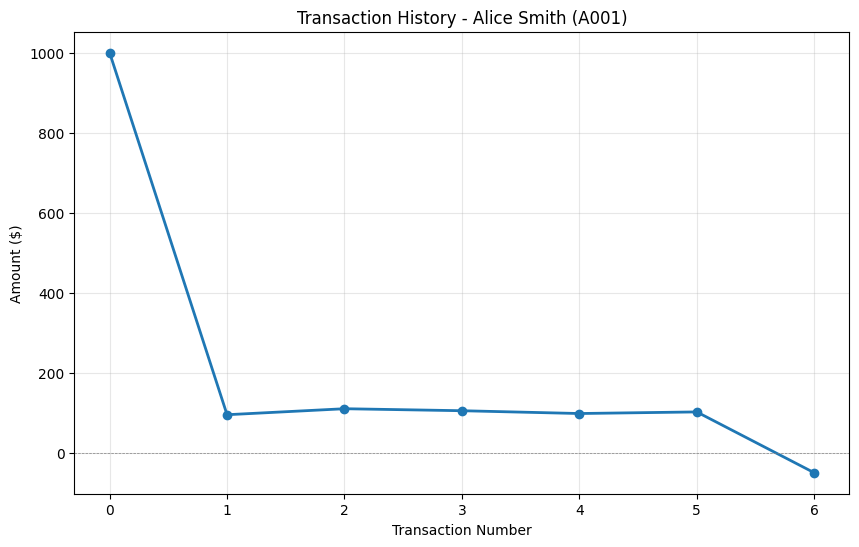

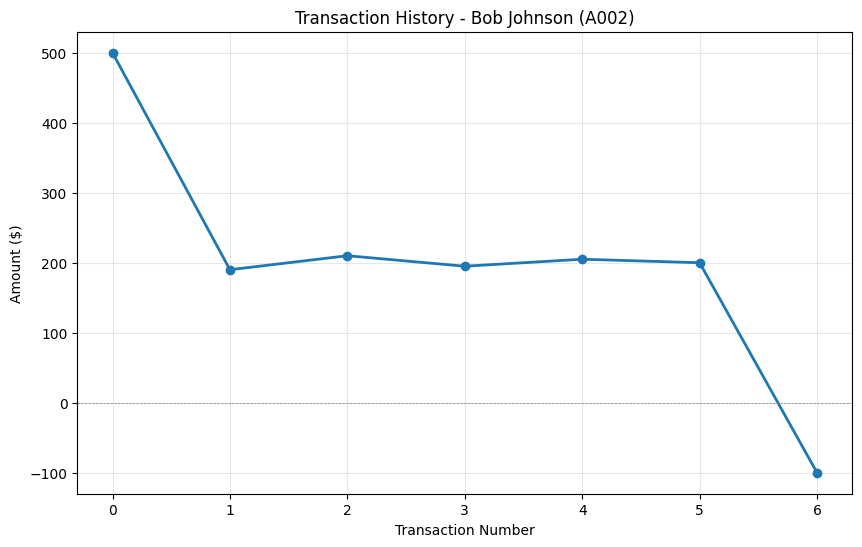

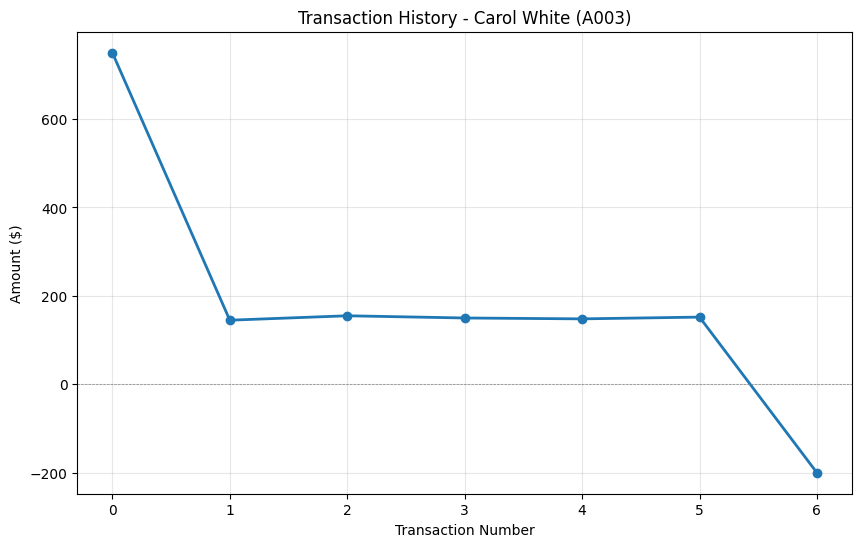

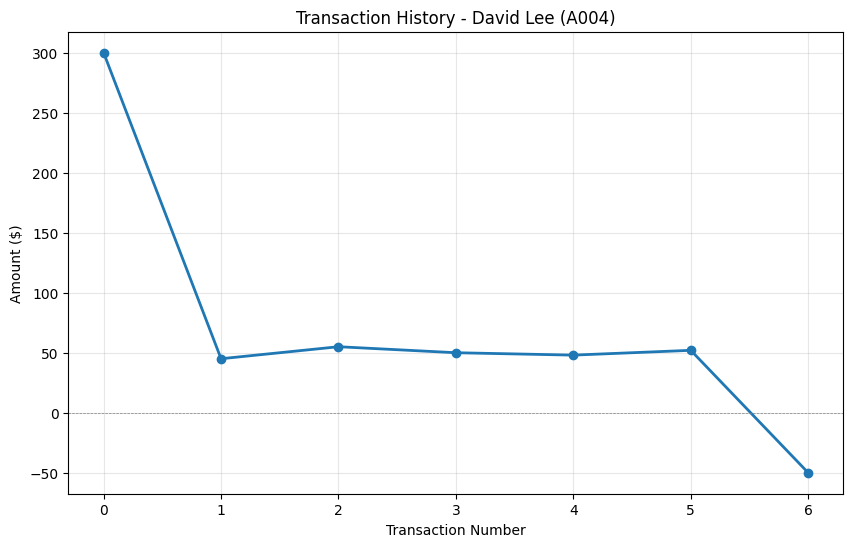

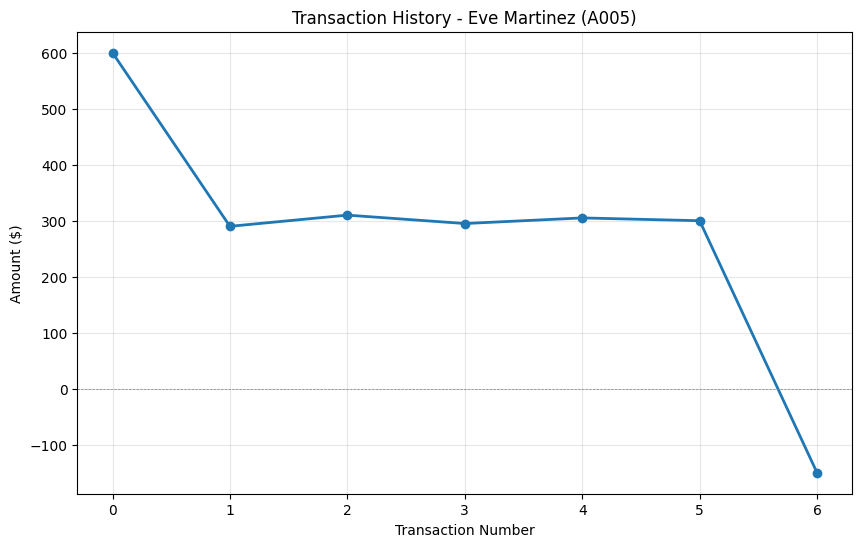

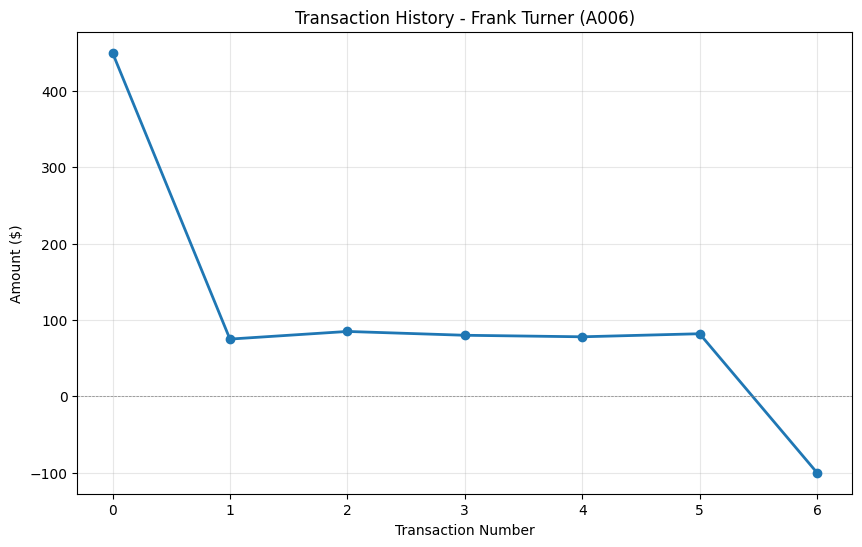

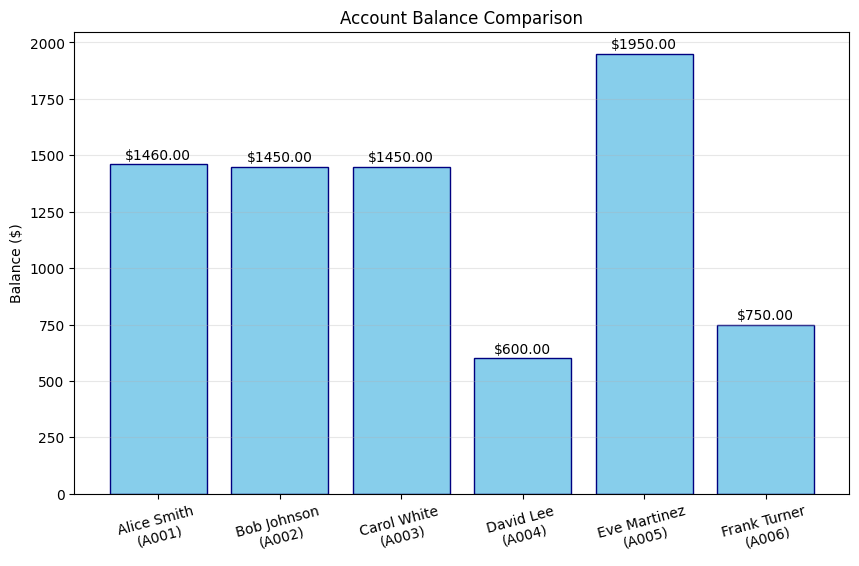

In [19]:
# visualizations of transactions
plot_transaction_amounts(alice)
plot_transaction_amounts(bob)
plot_transaction_amounts(carol)
plot_transaction_amounts(david)
plot_transaction_amounts(eve)
plot_transaction_amounts(frank)
plot_balance_comparison([alice, bob, carol, david, eve, frank])